In [1]:
import numpy as np
import pandas as pd
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import scipy.io as sio
from datetime import datetime
import os

# Get the current date and time
current_datetime = datetime.now()
curr_datetime = str(current_datetime.strftime("%Y%m%d_%H%M%S"))

# Select .mat files
data_mat = 'data/fmri_feat_20250128_062205.mat'
#data_mat = 'data/eeg_feat_20240710_151724.mat'
data = sio.loadmat(data_mat)
x = data['x2']
y = data['y']

classified_ie = 'results/test_fmri_classified_ie.mat'
#classified_ie = 'results/test_eeg_classified_ie.mat'
ie = sio.loadmat(classified_ie)
res_dir = os.path.split(classified_ie)
res_dir = res_dir[0]

# TFCE
def tfce_2d(data, H=2, E=0.5, dh=0.01):
    """
    Apply the TFCE (Threshold-Free Cluster Enhancement) algorithm to a 2D matrix.
    
    Parameters:
    - data: 2D numpy array of input data.
    - H: float, TFCE height exponent. H=2 is a default.
    - E: float, TFCE extent exponent. E=0.5 is a default.
    - dh: float, step size for height.
    
    Returns:
    - tfce_data: 2D numpy array of TFCE-enhanced data.
    """
    
    # Get the maximum data value
    max_value = np.max(data)

    # Initialize the output array
    tfce_data = np.zeros_like(data)

    s = [[0,1,0],
     [1,1,1],
     [0,1,0]]
    
    ind = 1
    # Iterate over possible heights
    for h in np.arange(0, max_value, dh):
        # Binarize the data at the current height
        binarized_data = data > h
        
        # Label the connected components
        labeled_data, num_features = ndimage.label(binarized_data, structure=s)
        
        # Calculate the size of each component
        component_sizes = ndimage.sum(binarized_data, labeled_data, range(1, num_features + 1))
        
        # Apply the TFCE formula
        for label_index, size in enumerate(component_sizes, start=1):
            tfce_data[labeled_data == label_index] += (h ** H) * (size ** E) * dh

        ind += 1
    
    return tfce_data

# Mask results outside the possible combinations of window sizes & possitions
lm = np.ones([20,26])
lt = np.fliplr(np.triu(np.ones([20,20]), k=0))
mask_mat = np.append(lm, lt, axis=1)


# Classification accuracy on the original data
acc = ie['acc']
acc = acc*mask_mat
acc_bal = ie['acc_bal']
acc_bal = acc_bal*mask_mat


# Classification accuracy on permuted data
acc_perm = ie['acc_perm']
acc_perm = acc_perm*mask_mat[:,:,None]

# Apply TFCE to the original matrix
tfce_result = tfce_2d(acc)

# Apply TFCE to the permuted matrix
n_perms = 5000
perm_tfce_max = np.zeros(n_perms)

for i in range(n_perms):
    tfce_perm = tfce_2d(acc_perm[:,:,i])
    perm_tfce_max[i] = np.max(tfce_perm)

# Calculate p-values for the observed data
p_values = np.zeros((tfce_result.shape[0]*tfce_result.shape[1]))

for i, tfce_observed_value in enumerate(tfce_result.flatten()):
    p_values[i] = np.sum(perm_tfce_max >= tfce_observed_value)/n_perms

p_values = p_values.reshape(tfce_result.shape)
p_thr = 0.05

tfce_mask = p_values < p_thr

# # Calculate variance of k-fold accuracies
# acc_kf = ie['acc_kf']
# var_acc_kf = np.var(acc_kf, axis=0)
# var_acc_kf_tfce_masked = var_acc_kf*tfce_mask

# # Calculate the globa maximum accuracy
# comb_metric = acc * (1 - var_acc_kf)
# comb_metric_tfce_masked = comb_metric*tfce_mask
# max_comb_metric = np.max(comb_metric_tfce_masked)*100
# max_comb_metric_index = np.unravel_index(np.argmax(comb_metric_tfce_masked), comb_metric_tfce_masked.shape)

# # Get the corresponding maximum accuracy and balanced accuracy
# max_acc = acc[max_comb_metric_index[0],max_comb_metric_index[1]]*100
# max_acc_bal = acc_bal[max_comb_metric_index[0],max_comb_metric_index[1]]*100

# Find the window size and position of the maximum accuracy
#wp = np.arange(-0.5, -5, -0.1).round(1)
#ws = np.arange(0.1, 2, 0.1).round(1)



In [26]:
# Find the maximum value of classification accuracy
acc_tfce_masked = acc*tfce_mask
max_acc = np.max(acc_tfce_masked)*100
max_acc_idx = np.unravel_index(np.argmax(acc_tfce_masked), acc_tfce_masked.shape)

print(max_acc_idx)

wp = np.arange(-0.5, -5.1, -0.1).round(1)
ws = np.arange(0.1, 2.1, 0.1).round(1)

max_acc_wp = wp[max_acc_idx[1]]
max_acc_ws = ws[max_acc_idx[0]]

max_acc_bal = acc_bal[max_acc_idx[0],max_acc_idx[1]]*100

print(f'Maximum accuracy of {max_acc:.1f} % (balanced accuracy {max_acc_bal:.1f}) found in a window of a size {max_acc_ws:.1f} sec, and {max_acc_wp:.1f} sec before the beep')


(np.int64(0), np.int64(36))
Maximum accuracy of 65.4 % (balanced accuracy 64.3) found in a window of a size 0.1 sec, and -4.1 sec before the beep


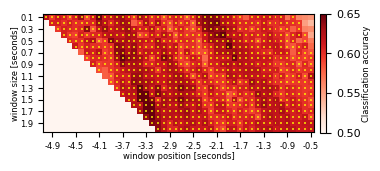

In [36]:

# # Select the best set of features for the combined fMRI+EEG classifier
# xx = x[:,:,max_comb_metric_index[0],max_comb_metric_index[1]]
# xy = np.append(xx, y, axis=1)
# best_feat_file = os.path.join(res_dir, 'best_feature.csv')
# np.savetxt(best_feat_file, xy, delimiter=',')

# # Save the corresponding confusion matrix
# cm = ie['cm']
# best_cm = cm[:,:,max_comb_metric_index[0],max_comb_metric_index[1]]
# best_cm_file = os.path.join(res_dir, 'best_cm.csv')
# np.savetxt(best_cm_file, best_cm, delimiter=',', fmt='%d')

# # Save the predicted labels of the best classifier
# y_hat = ie['y_hat']
# best_y_hat = y_hat[:,max_comb_metric_index[0],max_comb_metric_index[1]]
# best_y_hat_file = os.path.join(res_dir, 'y_hat.csv')
# np.savetxt(best_y_hat_file, best_y_hat, delimiter=',', fmt='%d')

# # Save the TFCE mask
# tfce_mask_file = os.path.join(res_dir, 'tfce_mask.csv')
# np.savetxt(tfce_mask_file, tfce_mask, delimiter=',', fmt='%d')

# max_comb_metric_matrix = np.zeros(np.shape(comb_metric))
# max_comb_metric_matrix[max_comb_metric_index] = 1

# Plot TFCE results
figsize = (10/2.54, 5/2.54)  # Convert cm to inches for figsize
fig = plt.figure(figsize=figsize)

plt.imshow(np.fliplr(acc), cmap='Reds', vmin=0.5, vmax=0.65)
cbar = plt.colorbar(shrink=0.75, pad=0.02)
cbar.ax.yaxis.set_tick_params(labelsize=8)
cbar.set_label(label='Classification accuracy', fontsize=6, labelpad=1)

highlight_tfce_y, highlight_tfce_x = np.where(np.fliplr(tfce_mask))
plt.scatter(highlight_tfce_x, highlight_tfce_y, color='yellow', marker='s', s=2, edgecolor='none', alpha=0.7)

#highlight_mcm_y, highlight_mcm_x = np.where(np.fliplr(max_comb_metric_matrix))
#plt.scatter(row_max, col_max, color='black', marker='o', s=2, edgecolor='black', label='max accuracy', alpha=0.95)

y_step = 2
y_ticks = np.arange(0, acc.shape[0], y_step)
y_labels = ws[::y_step]

x_step = 4
x_ticks = np.arange(1, acc.shape[1], x_step)
x_labels = np.flipud(wp[::x_step])

plt.xlabel('window position [seconds]', fontsize=6, labelpad=1)
plt.xticks(x_ticks,x_labels, fontsize=6)
plt.yticks(y_ticks,y_labels, fontsize=6)
plt.ylabel('window size [seconds]', fontsize=6, labelpad=1)
plt.tight_layout()
plt.show()

#fig_file = os.path.join(res_dir,('tfce_acc.svg'))
#fig.savefig(fig_file, format='svg', bbox_inches='tight')
